# Illustration of FFT vs wavelet transforms on signals strongly modulated in time

To analyze a signal that is stationary in time, the FFT is a very good method. But if the signal is modulated in time, i.e. the frequency content changes in time, then other methods, and in particular wavelets, are better suited.

This uses some data from the paper:

https://www.cambridge.org/core/journals/journal-of-glaciology/article/estimating-the-elastic-modulus-of-landfast-ice-from-wave-observations/61588A5D2C4B0F99E79833A07450BB15

"Estimating the elastic modulus of landfast ice from wave observations"
Joey J. Voermans, Jean Rabault, Aleksey Marchenko, Takehiko Nose, Takuji Waseda,  Alexander V. Babanin
Journal of Glaciology, 2023

to illustrate this

In [1]:
from pathlib import Path

import pywt

import ssqueezepy

from data_loading import GeophoneMatData
from data_loading import geophone_fs, geophone_sampling_period
from data_loading import load_preprocess_geophone_matfile, show_Z_x1000

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from scipy import signal

import numpy as np

from icecream import ic

ic.configureOutput(prefix='', outputFunction=print)

***** Put the interpreter in UTC, to make sure no TZ issues


In [2]:
# Utility to plot wavelet shapes
# Note that choosing the right kind of wavelet (number of periods, how fast it grows and decays) to match the
# characteristics of the underlying signal is critical for good results!
# So it is a good idea to visualize the wavelet and wonder "is this wavelet well adpated to the signal I need to process?"


def plot_cwt_wavelet(wavelet, scale):
    # taken from https://pywavelets.readthedocs.io/en/latest/ref/cwt.html
    width = wavelet.upper_bound - wavelet.lower_bound
    int_psi, x = pywt.integrate_wavelet(wavelet, precision=10)
    step = x[1] - x[0]
    j = np.floor(
        np.arange(scale * width + 1) / (scale * step))
    if np.max(j) >= np.size(int_psi):
        j = np.delete(j, np.where((j >= np.size(int_psi)))[0])
    j = j.astype(np.int_)

    # normalize int_psi for easier plotting
    int_psi /= np.abs(int_psi).max()

    # discrete samples of the integrated wavelet
    filt = int_psi[j][::-1]

    nt = len(filt)
    t = np.linspace(-nt//2, nt//2, nt)

    plt.figure()
    plt.plot(t, filt.real, label="real")
    plt.plot(t, filt.imag, label="imag")
    plt.legend()
    plt.xlabel("time (sample #)")
    plt.ylabel("wavelet")
    plt.tight_layout()

100%|████████████████████████████████████████████████████████████████████████| 900674/900674 [00:11<00:00, 75912.97it/s]


********** show full signal **********


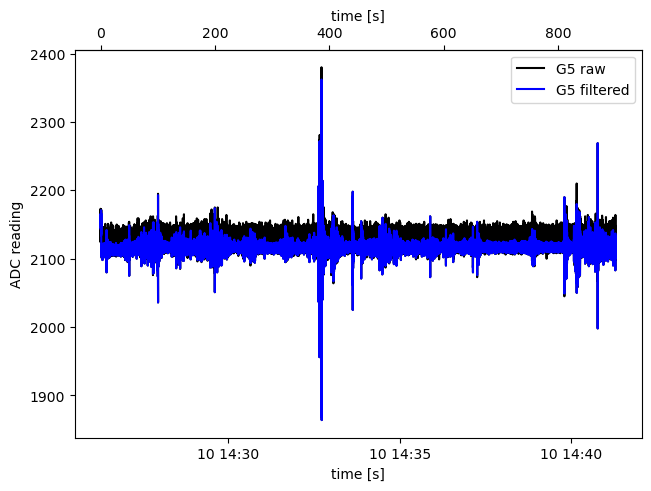

********** show specific part of the signal **********


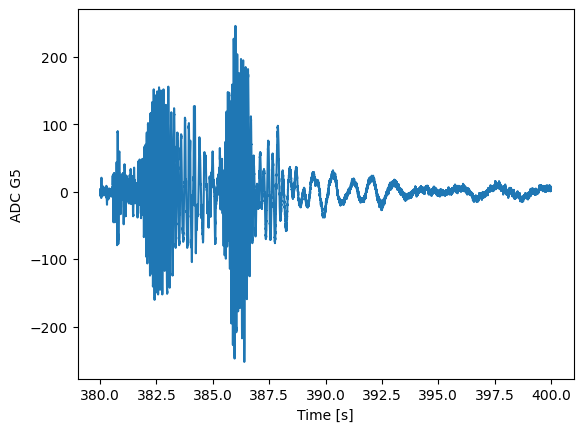

In [3]:
# load the data and plot them
# we only look at a small part of the data - a specific event with a couple of waves propagating through the ice and
# being received by the sensor

filename = "F00000094.mat"
path_to_data = Path.cwd() / filename

geophone_mat_data = load_preprocess_geophone_matfile(path_to_data)

# saving space when doing cwt
# total signal duration is 15*60 = 900s
# this signal is far too long to take wt at once, as doing wt at high resolutions is CPU and RAM demanding
# look at a small part of the signal, focusing on a specific event
signal_sub_start = int(geophone_fs * 380)
signal_sub_end = int(geophone_fs * 400)
reduced_time_vector = np.arange(signal_sub_start, signal_sub_end, 1) / geophone_fs
reduced_signal = geophone_mat_data.G5_filtered[signal_sub_start:signal_sub_end]
reduced_signal = reduced_signal - np.mean(reduced_signal)

# skip some points on x axis when plotting pcolor to save resources
x_skip_factor = 100

print("********** show full signal **********")
show_Z_x1000(geophone_mat_data)
plt.xlabel("time [s]")
plt.ylabel("ADC reading")
plt.show()

print("********** show specific part of the signal **********")

plt.figure()
plt.plot(reduced_time_vector, reduced_signal)
plt.xlabel("Time [s]")
plt.ylabel("ADC G5")
plt.show()

********** with FFT **********


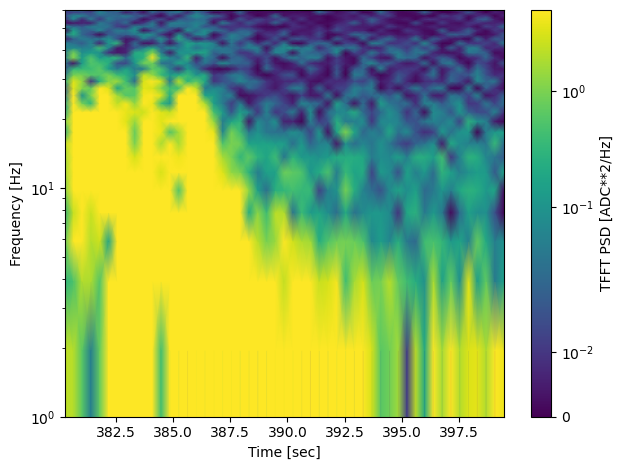

In [4]:
# do a transient FFT analysis
# for signals that vary so fast in time, this is not well adapted, and the whole picture is quite blurry

print("********** with FFT **********")

plt.figure()
f, t, Sxx = signal.spectrogram(reduced_signal, geophone_fs,
                               nperseg=512, noverlap=128)
plt.pcolormesh(
    t+380, f, Sxx,
    shading='gouraud',
    norm=colors.SymLogNorm(linthresh=0.02, linscale=1.0,
                           vmin=0.0, vmax=5.0),
)
plt.ylim(1, 60)
plt.yscale('log')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
colorbar = plt.colorbar()
colorbar.ax.set_ylabel('TFFT PSD [ADC**2/Hz]', rotation=90)
plt.tight_layout()

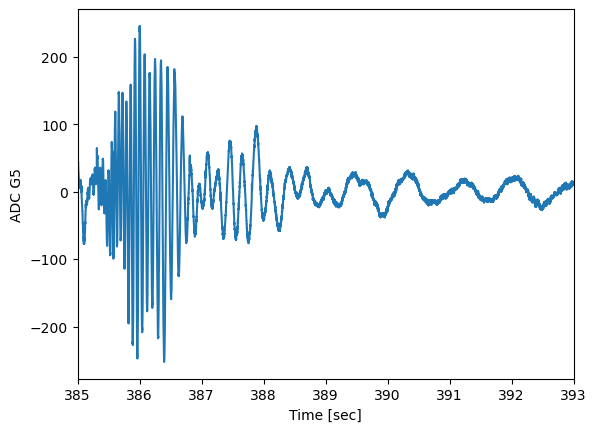

ContinuousWavelet cmor1.5-1.0
  Family name:    Complex Morlet wavelets
  Short name:     cmor
  Symmetry:       asymmetric
  DWT:            False
  CWT:            True
  Complex CWT:    True
cwt_matrix.shape: (50, 20000)


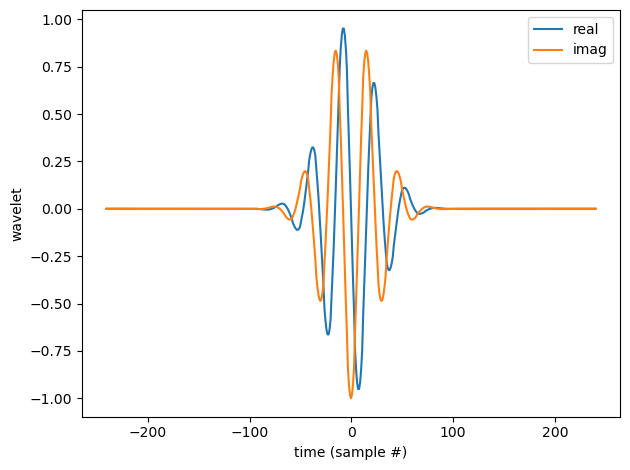

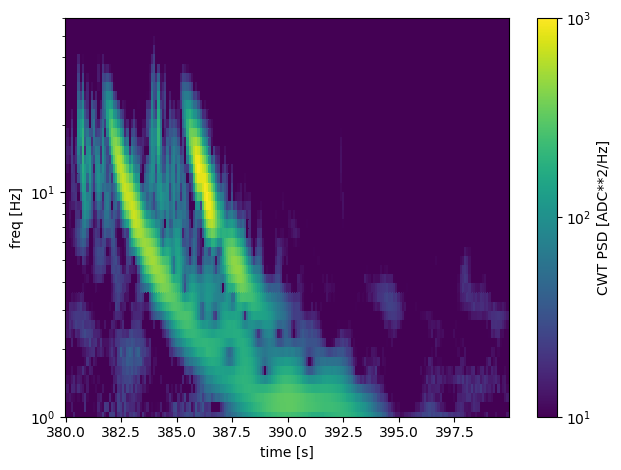

In [5]:
# do a "vanilla" wavelet analysis
# with a proper wavelet choice, this gives good resolution of the actual signal

# look at even a further zoom of the signal
plt.figure()
plt.plot(reduced_time_vector, reduced_signal)
plt.xlim([385, 393])
plt.xlabel("Time [sec]")
plt.ylabel("ADC G5")
plt.show()

# for info about wavelets and scaling, see: https://pywavelets.readthedocs.io/en/latest/ref/cwt.html
# we should a wavelet with a couple of oscillations - this is typically what is observed in our data before
# there is significant frequency change
scales = np.logspace(np.log10(10), np.log10(1000), 50)
wavelet = pywt.ContinuousWavelet('cmor1.5-1.0')

# show the wavelet we want to use: this should be well adapted to our signal
print(wavelet)
plot_cwt_wavelet(wavelet, 30)

# do the wavelet analysis
cwt_matrix, freqs = pywt.cwt(
    reduced_signal,
    scales,
    wavelet,
    sampling_period=geophone_sampling_period
)
ic(cwt_matrix.shape)

# Show w.r.t. time and frequency
plt.figure()
plt.pcolor(
    reduced_time_vector[::x_skip_factor], freqs, np.absolute(cwt_matrix)[:, ::x_skip_factor],
    norm=colors.SymLogNorm(linthresh=1.0, linscale=1.0,
                           vmin=1e1, vmax=1e3),
)
plt.ylim([1, 60])
plt.yscale('log')
plt.xlabel("time [s]")
plt.ylabel("freq [Hz]")
colorbar = plt.colorbar()
colorbar.ax.set_ylabel('CWT PSD [ADC**2/Hz]', rotation=90)
plt.tight_layout()

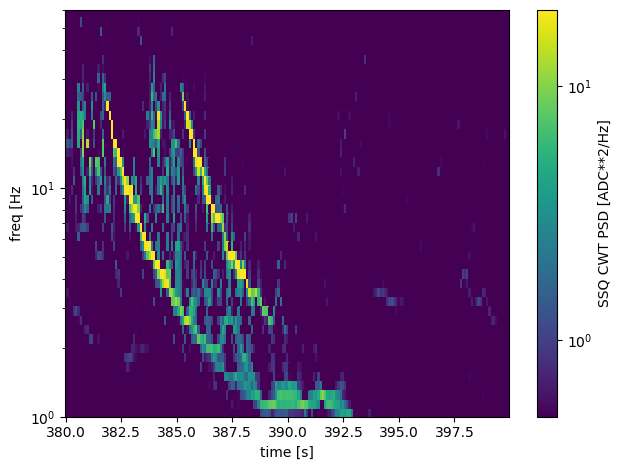

In [6]:
# more advanced methods can be used, to get better frequency resolution
# here, use the synchrosqueezing wavelet, see https://github.com/OverLordGoldDragon/ssqueezepy

scales = np.logspace(np.log10(10), np.log10(1000), 50)

Twx, Wx, ssq_freqs_c, scales, *_ = ssqueezepy.ssq_cwt(
    reduced_signal,
    fs=geophone_fs,
    wavelet=('morlet', {'mu': 4}),
    padtype='wrap',
    scales=scales,
    flipud=True
)

plt.figure()
plt.pcolor(
    reduced_time_vector[::x_skip_factor], ssq_freqs_c, np.absolute(Twx[:, ::x_skip_factor]),
    norm=colors.SymLogNorm(linthresh=0.001, linscale=1.0,
                           vmin=5e-1, vmax=2e1),
)
plt.ylim([1, 60])
plt.yscale('log')
plt.xlabel('time [s]')
plt.ylabel('freq [Hz')
colorbar = plt.colorbar()
colorbar.ax.set_ylabel('SSQ CWT PSD [ADC**2/Hz]', rotation=90)
plt.tight_layout()